In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

BASE_PATH = "/content/drive/My Drive/Datasets"


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
inventory = pd.read_csv(
    f"{BASE_PATH}/Inventory_Daily.csv",
    parse_dates=["business_date"]
)

receiving = pd.read_csv(
    f"{BASE_PATH}/Receiving_MultiDay.csv",
    parse_dates=["business_date"]
)

shipping = pd.read_csv(
    f"{BASE_PATH}/Shipping_MultiDay.csv",
    parse_dates=["business_date"]
)


SKU

In [ ]:
ship_daily = shipping.groupby(
    ["business_date", "item_id", "warehouse_id"],
    as_index=False
)["ship_qty"].sum()

recv_daily = receiving.groupby(
    ["business_date", "item_id", "warehouse_id"],
    as_index=False
)["received_qty"].sum()

df = inventory.merge(ship_daily, how="left") \
              .merge(recv_daily, how="left")

df.fillna(0, inplace=True)
df.sort_values(["item_id", "business_date"], inplace=True)


Rolling Features

In [ ]:
df["ship_7d_avg"] = df.groupby("item_id")["ship_qty"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)

df["ship_7d_std"] = df.groupby("item_id")["ship_qty"].transform(
    lambda x: x.rolling(7, min_periods=1).std().fillna(0)
)

df["inv_delta"] = df.groupby("item_id")["on_hand_qty"].diff().fillna(0)

df["recv_7d_avg"] = df.groupby("item_id")["received_qty"].transform(
    lambda x: x.rolling(7, min_periods=1).mean()
)


Shipment spikes & drop-offs

In [ ]:
features = df[["ship_qty", "ship_7d_avg", "ship_7d_std"]]

scaler = StandardScaler()
X = scaler.fit_transform(features)

iso_ship = IsolationForest(
    n_estimators=200,
    contamination=0.03,
    random_state=42
)

df["shipment_anomaly"] = iso_ship.fit_predict(X)
df["shipment_anomaly"] = df["shipment_anomaly"].map({-1: 1, 1: 0})


Over Receiving Trend

In [ ]:
features = df[["received_qty", "recv_7d_avg"]]
X = scaler.fit_transform(features)

iso_recv = IsolationForest(contamination=0.03, random_state=42)
df["receiving_anomaly"] = iso_recv.fit_predict(X)
df["receiving_anomaly"] = df["receiving_anomaly"].map({-1: 1, 1: 0})


Gradual inventory shrinkage

In [ ]:
df["inv_7d_slope"] = df.groupby("item_id")["on_hand_qty"].transform(
    lambda x: x.rolling(7, min_periods=3)
              .apply(lambda y: np.polyfit(range(len(y)), y, 1)[0], raw=False)
              .fillna(0)
)

iso_inv = IsolationForest(contamination=0.03, random_state=42)
df["inventory_shrink_anomaly"] = iso_inv.fit_predict(
    df[["inv_7d_slope"]]
)
df["inventory_shrink_anomaly"] = df["inventory_shrink_anomaly"].map({-1: 1, 1: 0})


Inventory hoarding

In [ ]:
features = df[["on_hand_qty", "ship_7d_avg"]]
X = scaler.fit_transform(features)

iso_hoard = IsolationForest(contamination=0.03, random_state=42)
df["inventory_hoarding"] = iso_hoard.fit_predict(X)
df["inventory_hoarding"] = df["inventory_hoarding"].map({-1: 1, 1: 0})


Seasonality breakModel: STL decomposition + Isolation Forest

In [ ]:
from statsmodels.tsa.seasonal import STL

def detect_seasonality_break(series):
    stl = STL(series, period=7, robust=True)
    res = stl.fit()
    return res.resid

df["seasonal_residual"] = df.groupby("item_id")["ship_qty"].transform(
    detect_seasonality_break
)

iso_season = IsolationForest(contamination=0.03, random_state=42)
df["seasonality_anomaly"] = iso_season.fit_predict(
    df[["seasonal_residual"]].fillna(0)
)
df["seasonality_anomaly"] = df["seasonality_anomaly"].map({-1: 1, 1: 0})


In [ ]:
df["ml_anomaly_flag"] = (
    df["shipment_anomaly"]
    | df["receiving_anomaly"]
    | df["inventory_shrink_anomaly"]
    | df["inventory_hoarding"]
    | df["seasonality_anomaly"]
)

Overall anomaly summary

In [ ]:
anomaly_cols = [
    "shipment_anomaly",
    "receiving_anomaly",
    "inventory_shrink_anomaly",
    "inventory_hoarding",
    "seasonality_anomaly"
]

summary = df[anomaly_cols].sum().reset_index()
summary.columns = ["anomaly_type", "anomaly_count"]

print(summary)


               anomaly_type  anomaly_count
0          shipment_anomaly            900
1         receiving_anomaly            896
2  inventory_shrink_anomaly            898
3        inventory_hoarding            900
4       seasonality_anomaly            899


In [ ]:
df["ml_anomaly_flag"] = (df[anomaly_cols].sum(axis=1) > 0).astype(int)

print(df["ml_anomaly_flag"].value_counts())


ml_anomaly_flag
0    26630
1     3370
Name: count, dtype: int64


In [ ]:
anomalies = df[df["ml_anomaly_flag"] == 1]

anomalies[[
    "business_date",
    "item_id",
    "warehouse_id",
    "on_hand_qty",
    "ship_qty",
    "received_qty",
    "shipment_anomaly",
    "receiving_anomaly",
    "inventory_shrink_anomaly",
    "inventory_hoarding",
    "seasonality_anomaly"
]].sort_values("business_date").head(20)


,business_date,item_id,warehouse_id,on_hand_qty,ship_qty,received_qty,shipment_anomaly,receiving_anomaly,inventory_shrink_anomaly,inventory_hoarding,seasonality_anomaly
0,2025-01-01,ITEM_00001,WH1,145,14.0,8.0,0,1,0,0,0
154,2025-01-01,ITEM_00155,WH1,460,0.0,26.0,1,0,0,1,0
155,2025-01-01,ITEM_00156,WH1,485,8.0,36.0,1,1,0,0,0
156,2025-01-01,ITEM_00157,WH1,169,26.0,26.0,1,0,0,0,0
390,2025-01-01,ITEM_00391,WH1,318,8.0,2.0,1,1,0,0,0
389,2025-01-01,ITEM_00390,WH1,576,1.0,11.0,1,0,0,1,0
53,2025-01-01,ITEM_00054,WH1,361,32.0,8.0,1,1,0,1,0
157,2025-01-01,ITEM_00158,WH1,443,1.0,5.0,1,1,0,1,0
468,2025-01-01,ITEM_00469,WH1,271,27.0,11.0,1,0,0,0,0
158,2025-01-01,ITEM_00159,WH1,451,32.0,0.0,1,1,0,1,0


In [ ]:
sku_anomaly_summary = df.groupby("item_id")[anomaly_cols].sum()
sku_anomaly_summary["total_anomalies"] = sku_anomaly_summary.sum(axis=1)

sku_anomaly_summary.sort_values("total_anomalies", ascending=False).head(10)


,shipment_anomaly,receiving_anomaly,inventory_shrink_anomaly,inventory_hoarding,seasonality_anomaly,total_anomalies
item_id,,,,,,
ITEM_00486,22,4,9,18,3,56
ITEM_00106,11,15,2,23,3,54
ITEM_00421,1,8,2,41,0,52
ITEM_00034,13,10,5,15,5,48
ITEM_00313,15,5,7,12,8,47
ITEM_00183,18,6,5,12,5,46
ITEM_00323,11,11,10,12,2,46
ITEM_00410,14,8,6,14,3,45
ITEM_00252,7,14,0,19,2,42


<Axes: title={'center': 'Daily ML Anomaly Count'}, xlabel='business_date'>

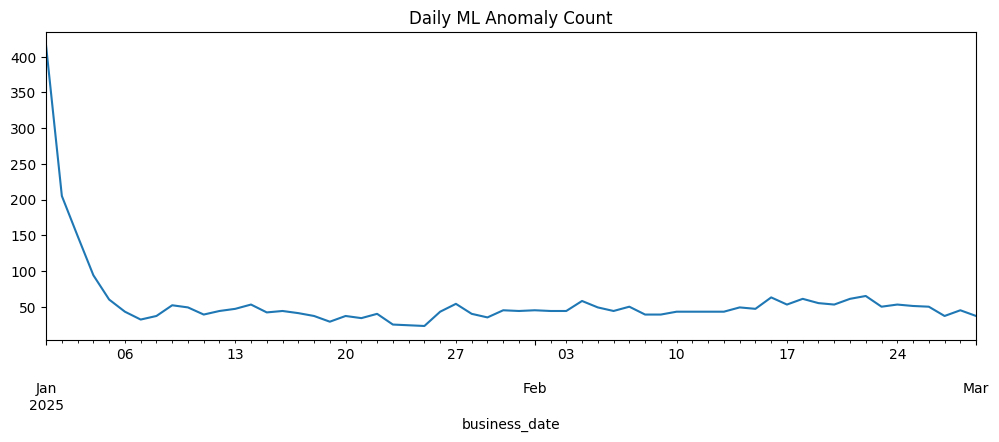

In [ ]:
daily_anomalies = df.groupby("business_date")["ml_anomaly_flag"].sum()

daily_anomalies.plot(
    figsize=(12,4),
    title="Daily ML Anomaly Count"
)


In [ ]:
anomalies.assign(
    anomaly_reason=anomalies[anomaly_cols]
        .idxmax(axis=1)
)[[
    "business_date",
    "item_id",
    "anomaly_reason"
]].head(20)


,business_date,item_id,anomaly_reason
0,2025-01-01,ITEM_00001,receiving_anomaly
5000,2025-01-11,ITEM_00001,seasonality_anomaly
13000,2025-01-27,ITEM_00001,seasonality_anomaly
21500,2025-02-13,ITEM_00001,seasonality_anomaly
25000,2025-02-20,ITEM_00001,inventory_shrink_anomaly
25500,2025-02-21,ITEM_00001,receiving_anomaly
26000,2025-02-22,ITEM_00001,receiving_anomaly
1001,2025-01-03,ITEM_00002,receiving_anomaly
17001,2025-02-04,ITEM_00002,inventory_shrink_anomaly
17501,2025-02-05,ITEM_00002,inventory_shrink_anomaly
